In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv
/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).xlsx


# 1. Preparation

## 1.1. Library

In [2]:
import re

## 1.2. Data Acq. - Get data from dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv")

In [4]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en


## 1.3. Data Engineering - Extract city from `Observ` column

The `observ` column contains semi-structured text with a consistent pattern.
We can leverage this pattern using regular expressions to extract the city name from each observation.

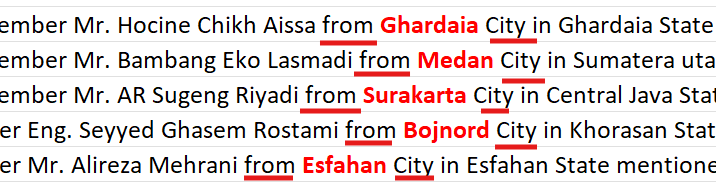


In [5]:
def extract_city(text):
    text = text.lower()
    
    match = re.search(r'from (.*?) city', text)
    if match:
        return match.group(1).strip().title()
    
    return None

In [6]:
df['city'] = df['observ'].apply(extract_city)

In [7]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source,city
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Ghardaia
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Medan
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Surakarta
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Bojnord
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Esfahan


In [8]:
print(df['city'].value_counts())

city
Surakarta                            251
Blacksburg                           240
Shahreza                             188
York                                 155
بنسليمان                             131
                                    ... 
سطات                                   1
إديني                                  1
بغداد، بصرة، الموصل                    1
بولاق الدكرور                          1
Mountain Shenly Dehaghan(Boodjan)      1
Name: count, Length: 808, dtype: int64
